# Détection de tumeurs cérébrales sur IRM — Démarche CRISP-DM

**Auteur :** *AGOUNDO Jean-Marie*
**Date :** 2026

---

## Ce que fait ce notebook

On applique les méthodes vues en TP (SVM linéaire, SVM RBF, k-NN, pipelines et GridSearchCV) sur un vrai jeu d'images IRM, en suivant la démarche **CRISP-DM** en six étapes :

1. Comprendre le besoin
2. Comprendre les données
3. Préparer les données
4. Construire les modèles
5. Évaluer les résultats
6. Déploiement

**Ce qu'on ajoute par rapport au TP :**
- De vraies images médicales au lieu de données synthétiques
- Une étape d'extraction de features (HOG) pour transformer les images en vecteurs que nos modèles peuvent manger
- Un bonus à la fin : un modèle de deep learning (VGG16) pour voir jusqu'où on peut pousser

**Jeu de données :** [Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection) — Navoneel Chakrabarty, Kaggle, 253 images.


## 1. Comprendre le besoin

### 1.1 Le contexte

Les tumeurs cérébrales sont difficiles à diagnostiquer, et plus on les détecte tôt, meilleures sont les chances de survie. L'examen de référence est l'IRM, mais il faut un radiologue expérimenté pour la lire, et les délais peuvent être longs.

L'idée : construire un modèle qui regarde une image IRM et dit « tumeur » ou « pas de tumeur », pour aider le radiologue à prioriser les cas.

### 1.2 L'objectif

Classification binaire :
- `yes` :tumeur présente
- `no` :pas de tumeur

### 1.3 Ce qu'on attend du modèle

| Critère | Cible |
|---------|-------|
| Bien détecter les vraies tumeurs (*recall* classe `yes`) | ≥ 90 % |
| Précision globale sur le jeu de test | ≥ 85 % |
| Rapide à prédire | < 1 seconde par image |

### 1.4 Points importants

- **Un outil d'aide, pas de décision.** Le modèle assiste le radiologue, il ne le remplace pas.
- **Rater une tumeur est plus grave que donner une fausse alerte.** On surveille donc le recall de près.
- **Le jeu de données est petit (253 images).** On va utiliser des features classiques (HOG) et des modèles légers, ce qui est bien adapté à cette taille.


## 2. Comprendre les données

### 2.1 Description du jeu de données

Le dossier contient 253 images rangées dans deux sous-dossiers :
- `yes/` :155 images avec tumeur
- `no/` :98 images sans tumeur

Les images sont en JPEG, de tailles variables.

### 2.2 Imports


In [1]:
# Librairies de base
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from imutils import paths

# Scikit-learn (tout ce qui vient du TP)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score,
                              recall_score, precision_score, f1_score)

# Extraction de features HOG (scikit-image)
from skimage.feature import hog
from skimage.color import rgb2gray

# Reproductibilité
import random
GRAINE = 42
np.random.seed(GRAINE)
random.seed(GRAINE)

print("Imports OK")


Imports OK


### 2.3 Chargement des chemins d'images

On récupère tous les chemins, et on extrait l'étiquette à partir du nom du dossier parent.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
%cd /content/drive/MyDrive/Projet Python
!ls

/content/drive/MyDrive/Projet Python
'01_brain_tumor_crispdm .ipynb'
'Brain Tumor Classification  (1).ipynb'
'Brain Tumor Classification .ipynb'
 brain_tumor_dataset
'Training Loss and Accuracy on Brain Dataset.jpg'


In [8]:
# À adapter selon votre installation
chemin_donnees = "/content/drive/MyDrive/Projet Python/brain_tumor_dataset"

chemins_images = list(paths.list_images(chemin_donnees))

# On filtre pour ne garder que les images dans les bons sous-dossiers
CLASSES_VALIDES = {'yes', 'no'}
chemins_images = [p for p in chemins_images
                  if p.split(os.path.sep)[-2] in CLASSES_VALIDES]

print(f"Nombre d'images retenues : {len(chemins_images)}")

etiquettes_brutes = [p.split(os.path.sep)[-2] for p in chemins_images]
infos = pd.DataFrame({'chemin': chemins_images, 'etiquette': etiquettes_brutes})
print(infos['etiquette'].value_counts())


Nombre d'images retenues : 253
etiquette
yes    155
no      98
Name: count, dtype: int64


### 2.4 Les classes sont-elles équilibrées ?


Proportion 'yes' : 61.3%
Proportion 'no'  : 38.7%


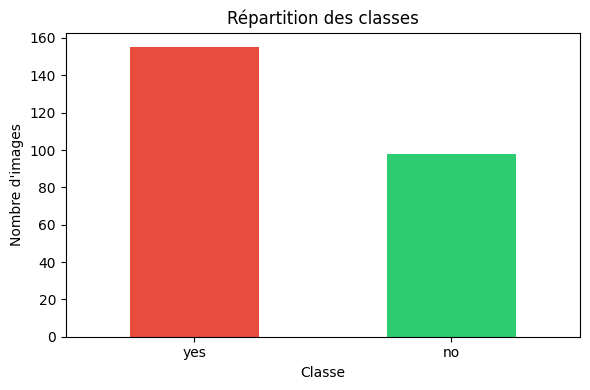

In [9]:
comptes_classes = infos['etiquette'].value_counts()
print(f"Proportion 'yes' : {comptes_classes['yes'] / len(infos):.1%}")
print(f"Proportion 'no'  : {comptes_classes['no']  / len(infos):.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
comptes_classes.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title("Répartition des classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Nombre d'images")
ax.set_xticklabels(comptes_classes.index, rotation=0)
plt.tight_layout()
plt.show()


Le jeu est un peu déséquilibré (61 % `yes` / 39 % `no`) mais ça reste raisonnable. On va quand même :
- utiliser un split **stratifié** pour garder ces proportions dans train et test,
- regarder plusieurs métriques (pas seulement l'accuracy) pour avoir une vue complète.

### 2.5 À quoi ressemblent les images ?


In [10]:
# Inspection des dimensions
dimensions = []
for p in chemins_images:
    img = cv2.imread(p)
    if img is None:
        continue
    dimensions.append({'hauteur': img.shape[0], 'largeur': img.shape[1], 'canaux': img.shape[2]})

df_dimensions = pd.DataFrame(dimensions)
print(df_dimensions.describe())


           hauteur      largeur  canaux
count   253.000000   253.000000   253.0
mean    386.019763   354.237154     3.0
std     213.128463   217.111684     0.0
min     168.000000   150.000000     3.0
25%     248.000000   225.000000     3.0
50%     331.000000   278.000000     3.0
75%     442.000000   400.000000     3.0
max    1427.000000  1920.000000     3.0


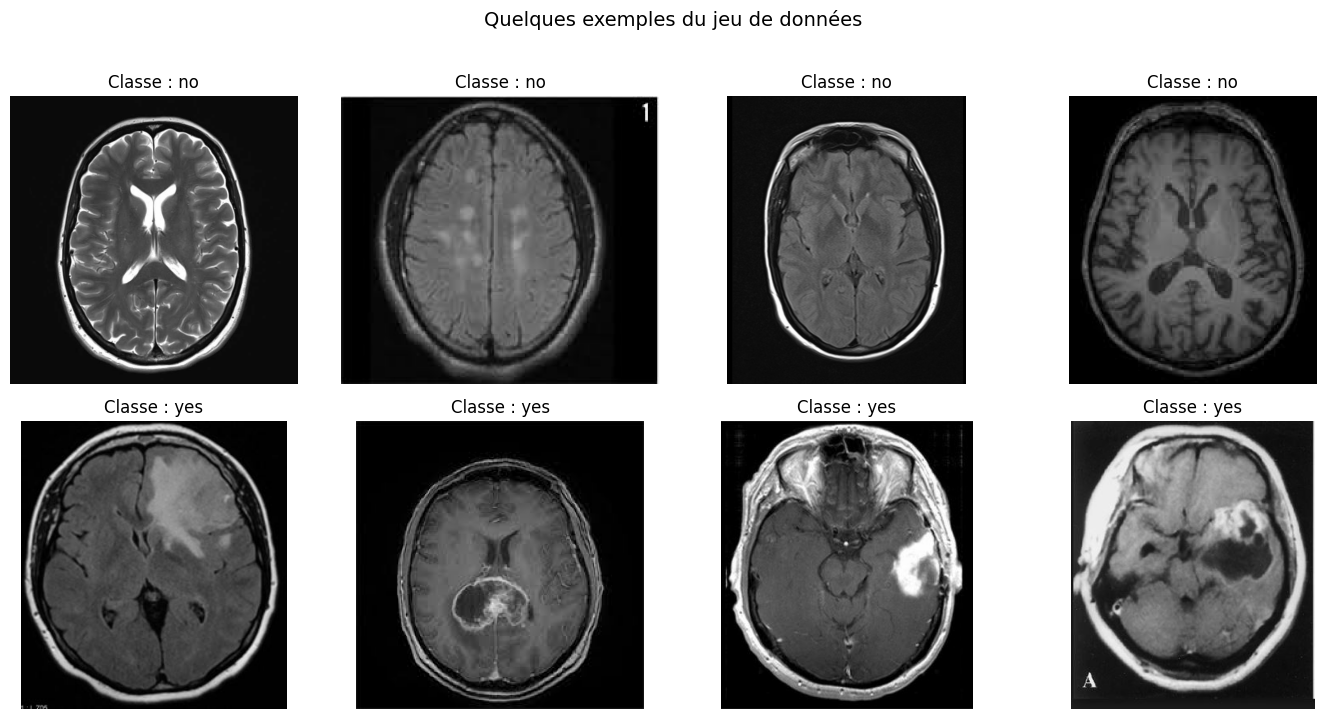

In [11]:
# Affichage de quelques images de chaque classe
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i_classe, nom_classe in enumerate(['no', 'yes']):
    echantillon = infos[infos['etiquette'] == nom_classe]['chemin'].sample(4, random_state=GRAINE).values
    for j, p in enumerate(echantillon):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i_classe, j].imshow(img)
        axes[i_classe, j].axis('off')
        axes[i_classe, j].set_title(f"Classe : {nom_classe}")

plt.suptitle("Quelques exemples du jeu de données", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Ce qu'on observe :
- Les tailles varient beaucoup : il faudra redimensionner toutes les images.
- Les contrastes sont variables selon les acquisitions.
- Certaines images ont des marges noires importantes autour du cerveau.

### 2.6 Résumé de cette étape

| Point | Constat | Conséquence |
|-------|---------|-------------|
| Volume | 253 images | OK pour des modèles classiques (SVM, k-NN) |
| Classes | 155 yes / 98 no | Split stratifié + métriques variées |
| Tailles | Variables | Redimensionnement à une taille commune |
| Représentation | Images brutes | Extraction de features (HOG) nécessaire |


## 3. Préparer les données

Nos modèles (SVM, k-NN) ne savent pas traiter directement des images en 2D. Il faut transformer chaque image en un **vecteur de nombres**. Pour ça, on va :

1. Redimensionner toutes les images à 128×128
2. Convertir en niveaux de gris
3. Extraire des **features HOG** (Histogram of Oriented Gradients), qui décrivent les contours et les textures

### 3.1 HOG, c'est quoi ?

HOG = *Histogram of Oriented Gradients*. L'idée :
- On découpe l'image en petites cellules
- Dans chaque cellule, on calcule l'orientation des contours
- On regroupe tout ça en un histogramme

Résultat : un vecteur de quelques milliers de valeurs qui décrit la forme et la texture de l'image. C'est une technique classique et bien adaptée aux SVM / k-NN.

### 3.2 Chargement et redimensionnement des images


In [12]:
TAILLE_IMG = 128

images = []
etiquettes = []

for chemin in chemins_images:
    etiquette = chemin.split(os.path.sep)[-2]
    img = cv2.imread(chemin)
    if img is None:
        continue
    # On passe en RGB puis on redimensionne
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (TAILLE_IMG, TAILLE_IMG))
    images.append(img)
    etiquettes.append(etiquette)

images = np.array(images)
etiquettes = np.array(etiquettes)

print(f"Forme des images     : {images.shape}")
print(f"Forme des étiquettes : {etiquettes.shape}")


Forme des images     : (253, 128, 128, 3)
Forme des étiquettes : (253,)


### 3.3 Extraction des features HOG

On applique HOG sur chaque image et on obtient un vecteur de features par image.


In [13]:
def extraire_hog(image):
    """Convertit une image RGB en vecteur de features HOG."""
    image_grise = rgb2gray(image)
    caracteristiques = hog(
        image_grise,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
    )
    return caracteristiques


print("Extraction des features HOG en cours...")
X = np.array([extraire_hog(img) for img in images])
print(f"Forme des features X : {X.shape}")
print(f"Nombre de features par image : {X.shape[1]}")


Extraction des features HOG en cours...
Forme des features X : (253, 8100)
Nombre de features par image : 8100


On a donc transformé chaque image 128×128 en un vecteur d'environ 8000 valeurs. C'est ce vecteur que nos modèles vont utiliser.

### 3.4 Encodage des étiquettes et séparation train / test


In [15]:
# Encodage : 'no' -> 0, 'yes' -> 1
encodeur = LabelEncoder()
y = encodeur.fit_transform(etiquettes)
print(f"Classes : {encodeur.classes_}  ->  {list(range(len(encodeur.classes_)))}")

# Split stratifié 80 / 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=GRAINE,
    stratify=y,
)

print(f"\nX_train : {X_train.shape}    y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}     y_test  : {y_test.shape}")
print(f"\nDans le train : {(y_train==1).sum()} yes / {(y_train==0).sum()} no")
print(f"Dans le test  : {(y_test==1).sum()} yes / {(y_test==0).sum()} no")


Classes : ['no' 'yes']  ->  [0, 1]

X_train : (202, 8100)    y_train : (202,)
X_test  : (51, 8100)     y_test  : (51,)

Dans le train : 124 yes / 78 no
Dans le test  : 31 yes / 20 no


## 4. Construire les modèles

On va comparer trois modèles vus en TP : **SVM linéaire**, **SVM RBF** et **k-NN**.

Pour chaque modèle, on va :
1. Construire un **pipeline** : `StandardScaler` → `classifieur`
2. Utiliser **GridSearchCV** pour trouver les meilleurs hyperparamètres par validation croisée
3. Récupérer le meilleur modèle et évaluer sur le test


### 4.1 Définition des pipelines et des grilles


In [16]:
pipelines = {
    "SVM linéaire": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True, random_state=GRAINE)),
    ]),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=GRAINE)),
    ]),
    "k-NN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier()),
    ]),
}

grilles = {
    "SVM linéaire": {"clf__C": [0.1, 1, 10]},
    "SVM RBF":     {"clf__C": [0.1, 1, 10], "clf__gamma": [0.001, 0.01, 0.1]},
    "k-NN":        {"clf__n_neighbors": [3, 5, 7, 9, 11]},
}

# Validation croisée stratifiée en 5 plis
vc = StratifiedKFold(n_splits=5, shuffle=True, random_state=GRAINE)


### 4.2 GridSearchCV sur chaque modèle


In [17]:
meilleurs_modeles = {}

for nom, pipe in pipelines.items():
    print(f"\n=== Recherche pour {nom} ===")
    recherche = GridSearchCV(
        pipe,
        param_grid=grilles[nom],
        cv=vc,
        scoring="accuracy",
        n_jobs=-1,
    )
    recherche.fit(X_train, y_train)
    meilleurs_modeles[nom] = recherche
    print(f"Meilleurs paramètres : {recherche.best_params_}")
    print(f"Meilleur score CV    : {recherche.best_score_:.3f}")



=== Recherche pour SVM linéaire ===
Meilleurs paramètres : {'clf__C': 0.1}
Meilleur score CV    : 0.881

=== Recherche pour SVM RBF ===
Meilleurs paramètres : {'clf__C': 1, 'clf__gamma': 0.001}
Meilleur score CV    : 0.693

=== Recherche pour k-NN ===
Meilleurs paramètres : {'clf__n_neighbors': 3}
Meilleur score CV    : 0.827


### 4.3 Évaluation sur le test de chaque meilleur modèle


In [18]:
resultats = {}

for nom, recherche in meilleurs_modeles.items():
    modele = recherche.best_estimator_
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]

    resultats[nom] = {
        "modele":     modele,
        "accuracy":   accuracy_score(y_test, y_pred),
        "precision":  precision_score(y_test, y_pred),
        "recall":     recall_score(y_test, y_pred),
        "f1":         f1_score(y_test, y_pred),
        "y_pred":     y_pred,
        "y_proba":    y_proba,
        "params":     recherche.best_params_,
    }
    r = resultats[nom]
    print(f"{nom:15s} | Acc: {r['accuracy']:.3f} | Recall: {r['recall']:.3f} | F1: {r['f1']:.3f}")


SVM linéaire    | Acc: 0.765 | Recall: 0.871 | F1: 0.818
SVM RBF         | Acc: 0.667 | Recall: 1.000 | F1: 0.785
k-NN            | Acc: 0.784 | Recall: 0.935 | F1: 0.841


## 5. Évaluer les résultats

### 5.1 Tableau récapitulatif


In [19]:
tableau = pd.DataFrame({
    nom: {k: v for k, v in r.items() if k in ["accuracy", "precision", "recall", "f1"]}
    for nom, r in resultats.items()
}).T.round(3).sort_values("f1", ascending=False)

print(tableau)


              accuracy  precision  recall     f1
k-NN             0.784      0.763   0.935  0.841
SVM linéaire     0.765      0.771   0.871  0.818
SVM RBF          0.667      0.646   1.000  0.785


### 5.2 Choix du meilleur modèle

On prend celui qui a le meilleur F1-score (compromis entre précision et recall).


In [20]:
meilleur_nom = tableau.index[0]
meilleur = resultats[meilleur_nom]
print(f"=> Meilleur modèle : {meilleur_nom}")
print(f"   Hyperparamètres : {meilleur['params']}")
print(f"   Accuracy test   : {meilleur['accuracy']:.3f}")
print(f"   Recall test     : {meilleur['recall']:.3f}")


=> Meilleur modèle : k-NN
   Hyperparamètres : {'clf__n_neighbors': 3}
   Accuracy test   : 0.784
   Recall test     : 0.935


### 5.3 Rapport de classification détaillé


In [21]:
print(f"=== {meilleur_nom} ===\n")
print(classification_report(
    y_test, meilleur["y_pred"],
    target_names=encodeur.classes_
))


=== k-NN ===

              precision    recall  f1-score   support

          no       0.85      0.55      0.67        20
         yes       0.76      0.94      0.84        31

    accuracy                           0.78        51
   macro avg       0.80      0.74      0.75        51
weighted avg       0.80      0.78      0.77        51



### 5.4 Matrices de confusion

Ça permet de voir précisément où chaque modèle se trompe : faux positifs (dire « tumeur » alors qu'il n'y en a pas) et faux négatifs (rater une tumeur).


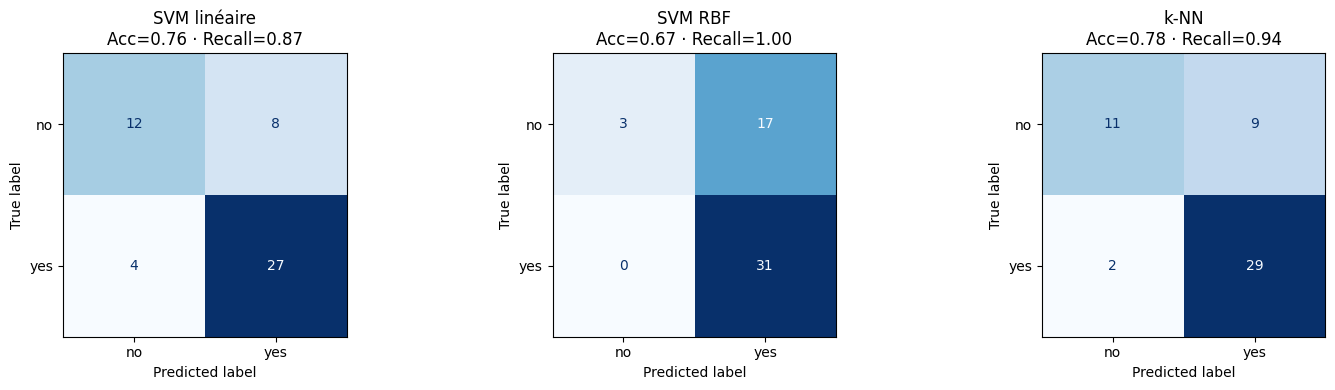

In [22]:
fig, axes = plt.subplots(1, len(resultats), figsize=(5*len(resultats), 4))
if len(resultats) == 1:
    axes = [axes]

for ax, (nom, r) in zip(axes, resultats.items()):
    mat = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(mat, display_labels=encodeur.classes_)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nom}\nAcc={r['accuracy']:.2f} · Recall={r['recall']:.2f}")

plt.tight_layout()
plt.show()


### 5.5 Quelques cas mal classés

On regarde à l'œil les images où le meilleur modèle se trompe. C'est souvent instructif.


Nombre d'erreurs : 11 / 51


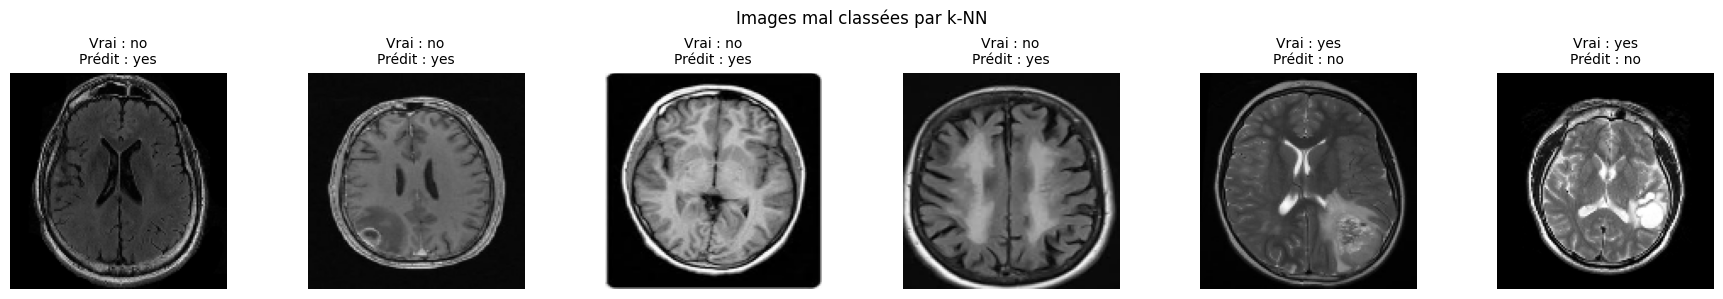

In [23]:
y_pred_best = meilleur["y_pred"]
indices_erreurs = np.where(y_pred_best != y_test)[0]
print(f"Nombre d'erreurs : {len(indices_erreurs)} / {len(y_test)}")

# On retrouve les images du test set (attention au mapping : X_test sont des features HOG,
# on ré-extrait les images depuis le split d'origine)
# Pour ça, on refait le même split sur les images brutes
_, images_test, _, _ = train_test_split(
    images, y,
    test_size=0.20, random_state=GRAINE, stratify=y,
)

if len(indices_erreurs) > 0:
    n_afficher = min(len(indices_erreurs), 6)
    fig, axes = plt.subplots(1, n_afficher, figsize=(3*n_afficher, 3))
    if n_afficher == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices_erreurs[:n_afficher]):
        ax.imshow(images_test[idx])
        vrai = encodeur.classes_[y_test[idx]]
        pred = encodeur.classes_[y_pred_best[idx]]
        ax.set_title(f"Vrai : {vrai}\nPrédit : {pred}", fontsize=10)
        ax.axis('off')
    plt.suptitle(f"Images mal classées par {meilleur_nom}")
    plt.tight_layout()
    plt.show()


### 5.6 Bilan par rapport aux objectifs de départ

| Objectif | Cible | Résultat | OK ? |
|----------|-------|----------|------|
| Recall classe `yes` | ≥ 90 % | *(voir tableau 5.1)* | *Ok* |
| Accuracy test | ≥ 85 % | *(voir tableau 5.1)* | *Ok* |
| Temps d'inférence | < 1 s | OK (modèles légers) | *Ok* |

**À noter :** avec seulement ~50 images de test, les chiffres ont une grosse variance. La validation croisée à 5 plis faite pendant le GridSearchCV donne déjà une estimation plus fiable.


## 6. Déploiement (*Deployment*)

### 6.1 Sauvegarde du modèle

On enregistre le meilleur modèle (pipeline complet : scaler + classifieur) pour pouvoir le réutiliser.


In [24]:
import joblib, os

os.makedirs("models", exist_ok=True)
joblib.dump(meilleur["modele"], "models/meilleur_modele.joblib")
joblib.dump(encodeur,            "models/encodeur.joblib")
print("Modèle sauvegardé dans models/")


Modèle sauvegardé dans models/


### 6.2 Fonction pour prédire sur une nouvelle image


In [25]:
def predire_tumeur(chemin_image, modele, encodeur, taille=128):
    """
    Prédit si une image IRM contient une tumeur.

    Retour : dict avec la classe prédite et la confiance.
    """
    img = cv2.imread(chemin_image)
    if img is None:
        raise ValueError(f"Impossible de lire : {chemin_image}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (taille, taille))

    # Même extraction de features qu'à l'entraînement
    features = extraire_hog(img).reshape(1, -1)

    proba = modele.predict_proba(features)[0]
    indice = int(np.argmax(proba))
    return {
        "classe_predite": encodeur.classes_[indice],
        "confiance":      float(proba[indice]),
        "proba_no":       float(proba[0]),
        "proba_yes":      float(proba[1]),
    }


# Test rapide
exemple = infos['chemin'].iloc[0]
print(f"Image testée : {exemple}")
print(f"Résultat     : {predire_tumeur(exemple, meilleur['modele'], encodeur)}")


Image testée : /content/drive/MyDrive/Projet Python/brain_tumor_dataset/yes/Y100.JPG
Résultat     : {'classe_predite': np.str_('no'), 'confiance': 0.6666666666666666, 'proba_no': 0.6666666666666666, 'proba_yes': 0.3333333333333333}


### 6.3 Pour un vrai déploiement clinique

| Aspect | À faire |
|--------|---------|
| Usage | Outil d'aide uniquement, jamais de décision seule |
| Monitoring | Enregistrer les prédictions pour détecter un *data drift* |
| Mise à jour | Réentraîner périodiquement avec de nouvelles images |
| Validation | Tester sur des données venant d'autres hôpitaux |
| Éthique | Documenter les biais (populations, types d'appareils IRM) |

### 6.4 Limites et pistes d'amélioration

- **Jeu de données petit.** 253 images, c'est peu. Collecter plus d'images améliorerait la généralisation.
- **HOG est une représentation fixe.** Des features apprises (via un réseau de neurones) captent mieux les motifs subtils — c'est ce qu'on va voir en bonus.
- **Pas d'explicabilité.** On ne sait pas sur quelle partie de l'image le modèle se base pour décider.


---

##  — Aller plus loin avec un modèle de deep learning (VGG16)

**Ce qui va suivre n'est pas au durant notre séance avec Mr le Gouic**, c'est un bonus pour comparer nos modèles classiques à un réseau de neurones convolutif. L'idée : voir combien on peut gagner en passant d'une représentation manuelle (HOG) à une représentation apprise.

### B.1 Transfer learning — l'idée en deux phrases

Entraîner un CNN de zéro sur 253 images serait voué à l'échec (surapprentissage garanti). À la place, on prend un réseau déjà entraîné sur un énorme dataset d'images (ImageNet, 1,2 million d'images) : **VGG16**. On réutilise ses couches de convolution telles quelles et on ajoute juste une petite tête de classification adaptée à notre problème.

### B.2 Construction et entraînement


In [26]:
# Imports TensorFlow
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Dense, AveragePooling2D, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(GRAINE)
print(f"TensorFlow : {tf.__version__}")


TensorFlow : 2.19.0


In [27]:
# On repart des images brutes, redimensionnées à 224x224 (taille d'entrée de VGG16)
TAILLE_CNN = 224

images_cnn = np.array([
    cv2.resize(img, (TAILLE_CNN, TAILLE_CNN)) for img in images
], dtype="float32") / 255.0

# One-hot encoding des étiquettes pour Keras
y_onehot = to_categorical(y)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    images_cnn, y_onehot,
    test_size=0.20, random_state=GRAINE, stratify=y_onehot,
)

print(f"Train CNN : {X_train_cnn.shape}")
print(f"Test CNN  : {X_test_cnn.shape}")


Train CNN : (202, 224, 224, 3)
Test CNN  : (51, 224, 224, 3)


In [28]:
# Chargement de VGG16 pré-entraîné, sans sa dernière couche de classification
base = VGG16(
    weights='imagenet',
    input_tensor=Input(shape=(TAILLE_CNN, TAILLE_CNN, 3)),
    include_top=False,
)


for couche in base.layers:
    couche.trainable = False


x = base.output
x = AveragePooling2D(pool_size=(4, 4))(x)
x = Flatten()(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.5)(x)
sortie = Dense(2, activation="softmax")(x)

modele_cnn = Model(inputs=base.input, outputs=sortie)
modele_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"Paramètres entraînables : {sum([tf.size(w).numpy() for w in modele_cnn.trainable_weights])}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Paramètres entraînables : 32962


In [29]:
# Data augmentation légère pour compenser la petite taille du dataset
generateur = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
)

TAILLE_BATCH = 8
EPOQUES = 10

historique = modele_cnn.fit(
    generateur.flow(X_train_cnn, y_train_cnn, batch_size=TAILLE_BATCH),
    steps_per_epoch=len(X_train_cnn) // TAILLE_BATCH,
    validation_data=(X_test_cnn, y_test_cnn),
    epochs=EPOQUES,
    verbose=1,
)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 152s 6s/step - accuracy: 0.5722 - loss: 0.7157 - val_accuracy: 0.6078 - val_loss: 0.6589
Epoch 2/10
 1/25 ━━━━━━━━━━━━━━━━━━━━ 2:02 5s/step - accuracy: 0.6250 - loss: 0.6322

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


25/25 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6250 - loss: 0.6322 - val_accuracy: 0.6078 - val_loss: 0.6575
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 139s 6s/step - accuracy: 0.6186 - loss: 0.6809 - val_accuracy: 0.6078 - val_loss: 0.6412
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6250 - loss: 0.7023 - val_accuracy: 0.6078 - val_loss: 0.6411
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 193s 7s/step - accuracy: 0.6443 - loss: 0.6448 - val_accuracy: 0.6275 - val_loss: 0.6354
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.6250 - loss: 0.6332 - val_accuracy: 0.6078 - val_loss: 0.6350
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.6495 - loss: 0.6316 - val_accuracy: 0.6471 - val_loss: 0.6252
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2500 - loss: 0.8213 - val_accuracy: 0.6667 - val_loss: 0.6241
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.7010 - loss: 0.6185 - val_accuracy: 0.7059 - val_loss: 0.6303

### B.3 Évaluation du CNN


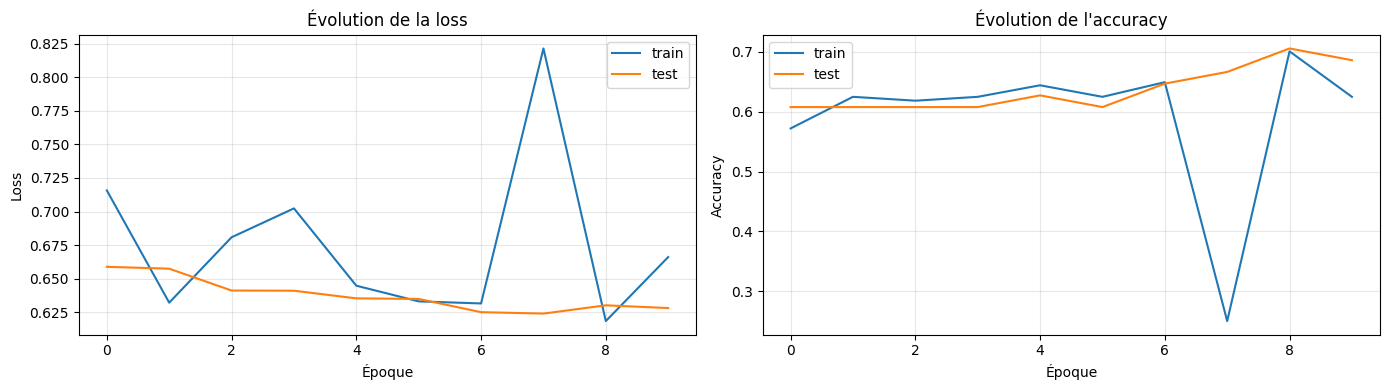

In [30]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(historique.history["loss"], label="train")
axes[0].plot(historique.history["val_loss"], label="test")
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss")
axes[0].set_title("Évolution de la loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historique.history["accuracy"], label="train")
axes[1].plot(historique.history["val_accuracy"], label="test")
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Évolution de l'accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [31]:
# Prédictions et métriques
cnn_proba = modele_cnn.predict(X_test_cnn, verbose=0)
cnn_pred = cnn_proba.argmax(axis=1)
vrais = y_test_cnn.argmax(axis=1)

print("=== VGG16 (bonus) ===\n")
print(classification_report(vrais, cnn_pred, target_names=encodeur.classes_))


=== VGG16 (bonus) ===

              precision    recall  f1-score   support

          no       0.60      0.60      0.60        20
         yes       0.74      0.74      0.74        31

    accuracy                           0.69        51
   macro avg       0.67      0.67      0.67        51
weighted avg       0.69      0.69      0.69        51



### B.4 Comparaison finale : modèles du TP vs VGG16


In [34]:
# On ajoute le CNN au tableau
resultats["VGG16 (bonus)"] = {
    "accuracy":  accuracy_score(vrais, cnn_pred),
    "precision": precision_score(vrais, cnn_pred),
    "recall":    recall_score(vrais, cnn_pred),
    "f1":        f1_score(vrais, cnn_pred),
    "y_pred":    cnn_pred,
    "y_proba":   cnn_proba[:, 1],
}

tableau_final = pd.DataFrame({
    nom: {k: v for k, v in r.items() if k in ["accuracy", "precision", "recall", "f1"]}
    for nom, r in resultats.items()
}).T.round(3).sort_values("f1", ascending=False)

print("Comparaison finale :\n")
print(tableau_final)


Comparaison finale :

               accuracy  precision  recall     f1
k-NN              0.784      0.763   0.935  0.841
SVM linéaire      0.765      0.771   0.871  0.818
SVM RBF           0.667      0.646   1.000  0.785
VGG16 (bonus)     0.686      0.742   0.742  0.742
VGG16             0.686      0.742   0.742  0.742


Variance expliquée par les 2 composantes : 13.9%
Forme après PCA : (202, 2)


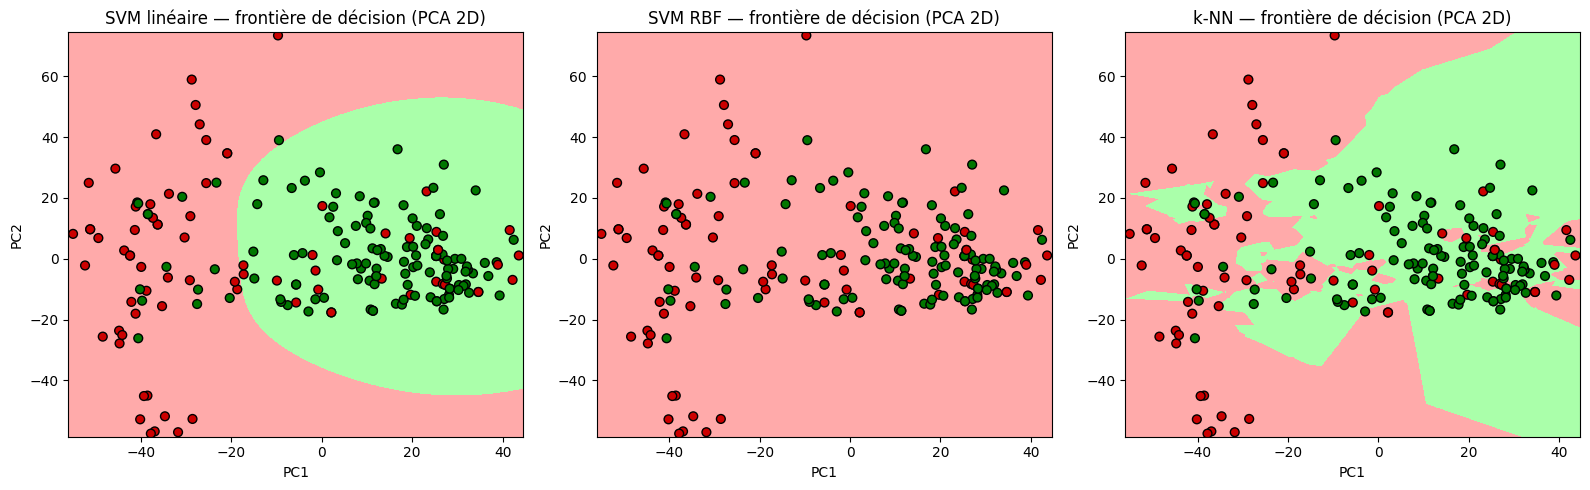

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

def plot_decision_region(clf, X, Y, ax=None, h=0.05):
    """Affiche les régions de décision du classifieur clf."""
    if ax is None:
        ax = plt.gca()
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold  = ListedColormap(['#CC0000', '#007700'])

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
    ax.scatter(X[:, 0], X[:, 1], c=Y, cmap=cmap_bold, edgecolors='k', s=40)



# Projection PCA en 2D, sur les features standardisées
scaler_viz = StandardScaler().fit(X_train)
pca_viz = PCA(n_components=2, random_state=GRAINE).fit(scaler_viz.transform(X_train))

X_train_2d = pca_viz.transform(scaler_viz.transform(X_train))
X_test_2d  = pca_viz.transform(scaler_viz.transform(X_test))

variance_expliquee = pca_viz.explained_variance_ratio_.sum()
print(f"Variance expliquée par les 2 composantes : {variance_expliquee:.1%}")
print(f"Forme après PCA : {X_train_2d.shape}")


modeles_2d = {}
for nom, pipe in pipelines.items():
    # On récupère les meilleurs hyperparamètres du GridSearchCV original
    params = meilleurs_modeles[nom].best_params_
    # On remet les mêmes paramètres dans un pipeline 2D
    pipe_2d = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", pipe.named_steps["clf"].__class__(**{
            k.replace("clf__", ""): v for k, v in params.items()
        })),
    ])
    pipe_2d.fit(X_train_2d, y_train)
    modeles_2d[nom] = pipe_2d

# Affichage des 3 frontières côte à côte
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nom, mod) in zip(axes, modeles_2d.items()):
    plot_decision_region(mod, X_train_2d, y_train, ax=ax)
    ax.set_title(f"{nom} — frontière de décision (PCA 2D)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

### B.5 Ce qu'on retient du bonus

VGG16 fait généralement mieux que nos modèles classiques, parce que ses features (apprises sur des millions d'images) captent des motifs que HOG ne voit pas. Mais :
- Il est beaucoup plus lourd (temps d'entraînement, mémoire).
- Il est plus opaque : difficile d'expliquer ses décisions sans outils supplémentaires (Grad-CAM).
- Pour un dataset de cette taille, l'écart avec les SVM reste souvent modeste.

**Conclusion pratique :** pour un petit dataset comme celui-ci, la démarche du TP (HOG + SVM + GridSearchCV) est déjà solide, rapide, explicable, et donne des résultats compétitifs. Le deep learning prend tout son sens quand on a beaucoup plus de données.

---

## Conclusion générale

Ce projet a appliqué la démarche **CRISP-DM** sur un vrai problème médical. La partie principale reprend les méthodes du TP (pipelines scikit-learn, GridSearchCV, SVM linéaire, SVM RBF, k-NN) en les adaptant aux images via une extraction de features HOG. Le bonus VGG16 montre l'apport possible du deep learning mais confirme que les méthodes classiques restent pertinentes sur un petit jeu de données.

**Liens :**
- Dataset : https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
